# Maximizing Revenue for Taxi Cab drivers through Payment Type Analysis

## Problem Statement

In the fast-paced taxi booking sector, maximizing the revenue for the driver is essential for long-term success and driver happiness. Our goal is to use data driven insights to maximize revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing and understand the customer group that uses our prefered mode of payment.

## Research Question

Is there a relationship between the total fare amount and payment type and how can we nudge customers towards payment methods that generate higher revenue for driver without negatively impacting customer experience?

## Objective

To examine the relationship between total fare and preferred method of payment if any.
We use descriptive statistics and hypothesis testing to extract useful information that can help drivers generate more cash. In particular we want to find out if there is a big difference in fares for those who pay through credit card vs those who pay in cash.

# Loading Packages

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from IPython.display import display, Markdown

import warnings

warnings.filterwarnings('ignore')

# Understanding the Data

[Information about the Data]

# Data Loading

In [2]:
'''

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

d = {}
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        d[filename] = pd.read_csv(os.path.join(dirname, filename))

df = d['yellow_tripdata_2015-01.csv']

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

'''

'\n\n# Input data files are available in the read-only "../input/" directory\n# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory\n\nd = {}\nfor dirname, _, filenames in os.walk(\'/kaggle/input\'):\n    for filename in filenames:\n        d[filename] = pd.read_csv(os.path.join(dirname, filename))\n\ndf = d[\'yellow_tripdata_2015-01.csv\']\n\n# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" \n# You can also write temporary files to /kaggle/temp/, but they won\'t be saved outside of the current session\n\n'

In [3]:
for dirname, _, filenames in os.walk('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue'):
    for filename in filenames:
        if filename == 'yellow_tripdata_2015-01.csv':
            df = pd.read_csv(os.path.join(dirname, filename))
        else:
            continue

# Initial Examination

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [5]:
df.shape

(12748986, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.8+ GB


# Data Collection

In [7]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   pickup_longitude       float64       
 6   pickup_latitude        float64       
 7   RateCodeID             int64         
 8   store_and_fwd_flag     object        
 9   dropoff_longitude      float64       
 10  dropoff_latitude       float64       
 11  payment_type           int64         
 12  fare_amount            float64       
 13  extra                  float64       
 14  mta_tax                float64       
 15  tip_amount             float64       
 16  tolls_amount           float64       
 17  improvement_surcharge  float64       
 18  total_amount        

In [8]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05,18.050000
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80,19.833333
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80,10.050000
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,1.866667
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30,19.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12748981,1,2015-01-10 19:01:44,2015-01-10 19:05:40,2,1.00,-73.951988,40.786217,1,N,-73.953735,40.775162,1,5.5,0.0,0.5,1.25,0.0,0.3,7.55,3.933333
12748982,1,2015-01-10 19:01:44,2015-01-10 19:07:26,2,0.80,-73.982742,40.728184,1,N,-73.974976,40.720013,1,6.0,0.0,0.5,2.00,0.0,0.3,8.80,5.700000
12748983,1,2015-01-10 19:01:44,2015-01-10 19:15:01,1,3.40,-73.979324,40.749550,1,N,-73.969101,40.787800,2,13.5,0.0,0.5,0.00,0.0,0.3,14.30,13.283333
12748984,1,2015-01-10 19:01:44,2015-01-10 19:17:03,1,1.30,-73.999565,40.738483,1,N,-73.981819,40.737652,1,10.5,0.0,0.5,2.25,0.0,0.3,13.55,15.316667


In [9]:
df = df[['passenger_count', 'trip_distance', 'payment_type', 'fare_amount', 'duration']]
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.59,1,12.0,18.050000
1,1,3.30,1,14.5,19.833333
2,1,1.80,2,9.5,10.050000
3,1,0.50,2,3.5,1.866667
4,1,3.00,2,15.0,19.316667
...,...,...,...,...,...
12748981,2,1.00,1,5.5,3.933333
12748982,2,0.80,1,6.0,5.700000
12748983,1,3.40,2,13.5,13.283333
12748984,1,1.30,1,10.5,15.316667


# Data Cleaning

In [10]:
# Checking for missing values

df.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
duration           0
dtype: int64

In [11]:
# Checking for right datatypes

df.dtypes

passenger_count      int64
trip_distance      float64
payment_type         int64
fare_amount        float64
duration           float64
dtype: object

In [12]:
# Checking for duplicate values

df.duplicated().sum()

7930427

In [13]:
df.drop_duplicates(inplace = True)

In [14]:
df.shape

(4818559, 5)

# Univariate Analysis

In [15]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.59,1,12.0,18.050000
1,1,3.30,1,14.5,19.833333
2,1,1.80,2,9.5,10.050000
3,1,0.50,2,3.5,1.866667
4,1,3.00,2,15.0,19.316667
...,...,...,...,...,...
12748955,1,10.71,1,40.0,44.016667
12748957,6,2.36,2,17.0,26.683333
12748958,5,3.88,2,14.5,14.166667
12748959,6,1.69,1,11.5,15.900000


In [16]:
# Looking at categorical data

df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.522535
2    0.186238
5    0.101820
3    0.075145
6    0.072250
4    0.040720
0    0.001284
9    0.000002
8    0.000002
7    0.000002
Name: proportion, dtype: float64

In [17]:
df = df[(df['passenger_count']>0) & (df['passenger_count']<7)]
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.523211
2    0.186478
5    0.101952
3    0.075242
6    0.072344
4    0.040773
Name: proportion, dtype: float64

In [18]:
df['payment_type'].value_counts(normalize = True)

payment_type
1    6.029339e-01
2    3.894546e-01
3    5.500027e-03
4    2.111031e-03
5    4.155982e-07
Name: proportion, dtype: float64

In [19]:
df = df[df['payment_type']<3]
df['payment_type'].value_counts(normalize = True)

payment_type
1    0.607558
2    0.392442
Name: proportion, dtype: float64

In [20]:
df['payment_type'].replace([1, 2], ['Card', 'Cash'], inplace = True)
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.59,Card,12.0,18.050000
1,1,3.30,Card,14.5,19.833333
2,1,1.80,Cash,9.5,10.050000
3,1,0.50,Cash,3.5,1.866667
4,1,3.00,Cash,15.0,19.316667
...,...,...,...,...,...
12748955,1,10.71,Card,40.0,44.016667
12748957,6,2.36,Cash,17.0,26.683333
12748958,5,3.88,Cash,14.5,14.166667
12748959,6,1.69,Card,11.5,15.900000


In [21]:
# Looking at numerical data

df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,4.775711e+06,4.775711e+06,4.775711e+06,4.775711e+06
mean,2.235436e+00,3.249170e+01,1.765919e+01,2.288912e+01
std,1.671725e+00,1.604972e+04,1.378450e+01,1.060785e+03
min,1.000000e+00,0.000000e+00,-4.500000e+02,-1.211017e+03
25%,1.000000e+00,1.660000e+00,9.000000e+00,9.966667e+00
50%,1.000000e+00,3.030000e+00,1.350000e+01,1.566667e+01
75%,3.000000e+00,5.800000e+00,2.150000e+01,2.310000e+01
max,6.000000e+00,1.542000e+07,4.008000e+03,5.485556e+05


In [22]:
# taking positive values only
df = df[df['trip_distance']>0]
df = df[df['fare_amount']>0]
df = df[df['duration']>0]
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,4.755645e+06,4.755645e+06,4.755645e+06,4.755645e+06
mean,2.237753e+00,3.262568e+01,1.759037e+01,2.291657e+01
std,1.672876e+00,1.608354e+04,1.319540e+01,1.062298e+03
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.670000e+00,9.000000e+00,1.001667e+01
50%,1.000000e+00,3.050000e+00,1.350000e+01,1.570000e+01
75%,3.000000e+00,5.830000e+00,2.150000e+01,2.313333e+01
max,6.000000e+00,1.542000e+07,4.008000e+03,5.485556e+05


{'whiskers': [<matplotlib.lines.Line2D at 0x1561cf0e0>,
 'caps': [<matplotlib.lines.Line2D at 0x1561cd280>,
 'boxes': [<matplotlib.lines.Line2D at 0x120fbbc50>],
 'medians': [<matplotlib.lines.Line2D at 0x1561cf9b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1561cfc80>],
 'means': []}

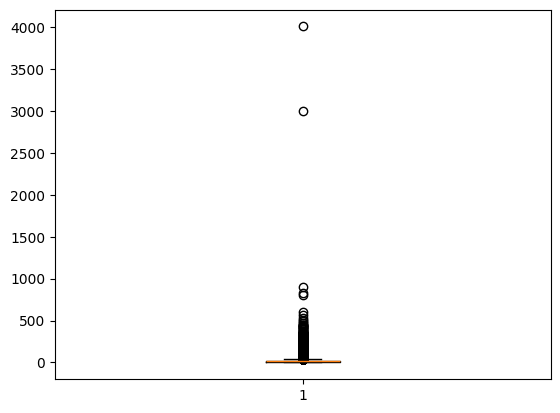

In [23]:
# outlier handling

plt.boxplot(df['fare_amount'])

In [24]:
for col in ['trip_distance', 'fare_amount', 'duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    lowerbound = q1 - 1.5 * iqr
    upperbound = q3 + 1.5 * iqr
    df = df[(df[col]>lowerbound) & (df[col]>upperbound)]

In [25]:
df['trip_distance'].describe()

count    1335.000000
mean       29.647738
std        18.454101
min        12.160000
25%        18.955000
50%        23.400000
75%        33.400000
max       181.960000
Name: trip_distance, dtype: float64

# Multivariate Analysis

In [26]:
df[df['payment_type']=='Card']

,passenger_count,trip_distance,payment_type,fare_amount,duration
1365,1,21.40,Card,92.8,120.916667
4879,1,25.42,Card,115.5,137.633333
15716,1,12.40,Card,67.0,95.983333
29002,1,56.80,Card,234.0,81.466667
34170,1,33.14,Card,140.0,92.050000
...,...,...,...,...,...
12555465,1,66.91,Card,297.0,106.016667
12569858,1,21.72,Card,95.0,124.816667
12579612,2,19.30,Card,110.5,130.383333
12584963,1,68.76,Card,316.0,82.316667


# Objective (i): 
Examine the relationship between total fare and method of payment. 
We use descriptive statistics here to extract useful information that can help drivers generate more cash. In particular we want to find out if there is a big difference in fares for those who pay through credit card vs those who pay in cash.

In [27]:
df.groupby('payment_type').agg(
    {
    'fare_amount': ['mean', 'std'],
    'trip_distance': ['mean', 'std']
    })

fare_amount            trip_distance           
                    mean        std          mean        std
payment_type                                                
Card          112.144008  65.865062     30.315168  19.289920
Cash          101.134120  48.443977     28.875719  17.421053

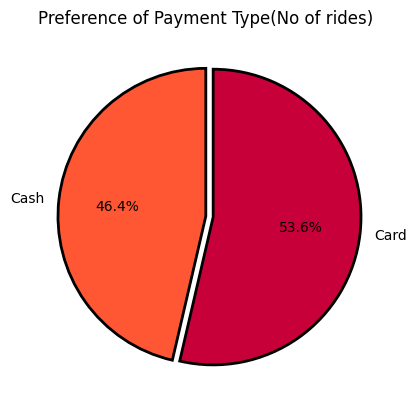

In [28]:
plt.title("Preference of Payment Type(No of rides)")
plt.pie([
            df[df['payment_type']=='Cash']['payment_type'].count(),
            df[df['payment_type']=='Card']['payment_type'].count()],
        labels = ['Cash', 'Card'], autopct='%1.1f%%', startangle=90, 
        colors = ['#FF5733', '#C70039'], explode = [0, 0.05],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.show()

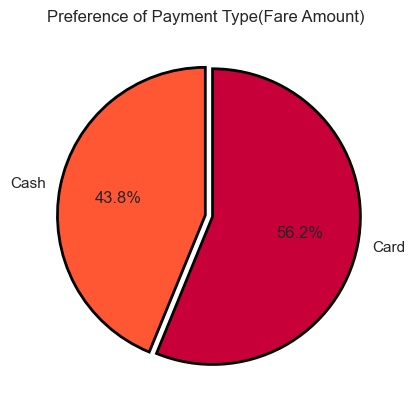

In [58]:
plt.title("Preference of Payment Type(Fare Amount)")
plt.pie([
            df[df['payment_type']=='Cash']['fare_amount'].sum(),
            df[df['payment_type']=='Card']['fare_amount'].sum()],
        labels = ['Cash', 'Card'], autopct='%1.1f%%', startangle=90, 
        colors = ['#FF5733', '#C70039'], explode = [0, 0.05],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue/images/paytype_by_fare_hist.png', dpi=300, bbox_inches='tight')
plt.show()

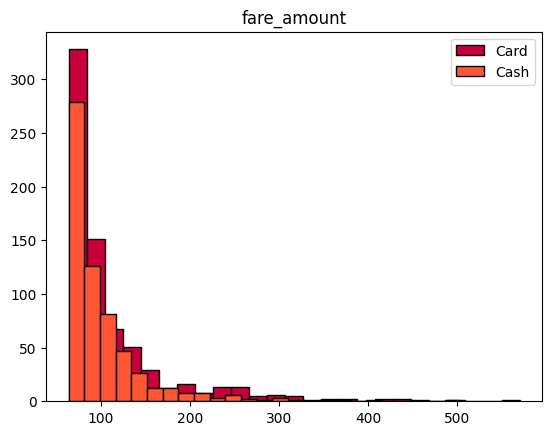

In [30]:
plt.figure()
plt.title('fare_amount')
plt.hist(df[df['payment_type']=='Card']['fare_amount'], bins = 25, label = 'Card', edgecolor = 'k', color = '#C70039')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'], bins = 25, label = 'Cash', edgecolor = 'k', color = '#FF5733')
plt.legend()
plt.show()

# Objective (ii):
Examine the relationships preferred mode of payment and other factors(other than total fare) like customer count, trip duration or trip distance.

# Payment Type and Customer Count

In [31]:
p_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()
p_count.rename(columns = {'passenger_count': 'count'}, inplace=True)
p_count['perc'] = (p_count['count']/p_count['count'].sum())*100
p_count.reset_index(inplace=True)
p_count

,payment_type,passenger_count,count,perc
0,Card,1,490,36.704120
1,Card,2,122,9.138577
2,Card,3,32,2.397004
3,Card,4,22,1.647940
4,Card,5,31,2.322097
5,Card,6,19,1.423221
6,Cash,1,398,29.812734
7,Cash,2,111,8.314607
8,Cash,3,52,3.895131
9,Cash,4,12,0.898876


In [32]:
new_df = pd.DataFrame(
    columns = ['payment_type', '1', '2', '3', '4', '5', '6'])
new_df['payment_type'] = ['Cash', 'Card']
new_df.iloc[0,1:] = p_count.iloc[6:,-1]
new_df.iloc[1,1:] = p_count.iloc[0:6,-1]
new_df['zero'] = [0, 0]

In [33]:
new_df

,payment_type,1,2,3,4,5,6,zero
0,Cash,29.812734,8.314607,3.895131,0.898876,1.722846,1.722846,0
1,Card,36.70412,9.138577,2.397004,1.64794,2.322097,1.423221,0


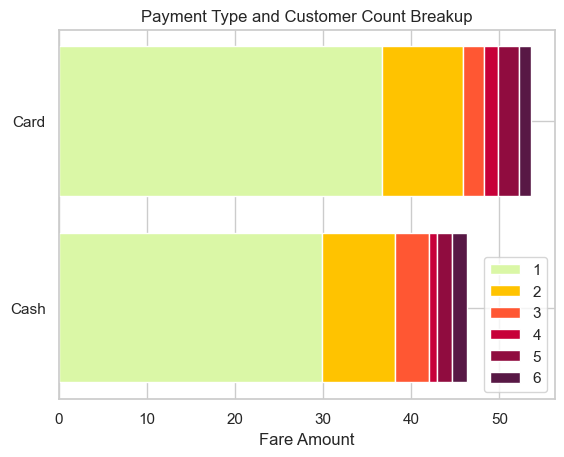

In [56]:
plt.title('Payment Type and Customer Count Breakup')
plt.xlabel('Fare Amount')
plt.yticks([0, 1], new_df['payment_type'])

color_list = ['#DAF7A6', '#FFC300', '#FF5733', '#C70039', '#900C3F', '#581845']

passenger_count_sum = new_df['zero']

for segment_color in color_list:
    passenger_count = new_df[str((color_list.index(segment_color))+1)]
    plt.barh(y = [0, 1], width = passenger_count,
             left = passenger_count_sum,
             color = segment_color, 
             label = str(color_list.index(segment_color)+1))
    passenger_count_sum = passenger_count_sum + passenger_count
    

plt.legend()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue/images/paytype_by_noofcust.png', dpi=300, bbox_inches='tight')
plt.show()

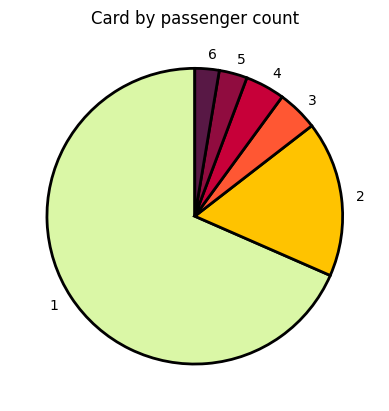

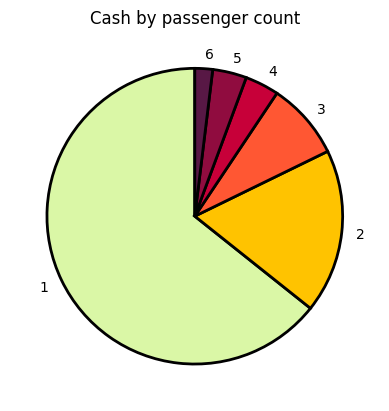

In [35]:
plt.title("Card by passenger count")
plt.pie(
        df[df['payment_type']=='Card']['passenger_count'].value_counts(),
        labels = [1, 2, 3, 4, 5, 6], startangle=90, 
        colors = ['#DAF7A6', '#FFC300', '#FF5733', '#C70039', '#900C3F', '#581845'],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.show()

plt.title("Cash by passenger count")
plt.pie(
        df[df['payment_type']=='Cash']['passenger_count'].value_counts(),
        labels = [1, 2, 3, 4, 5, 6], startangle=90, 
        colors = ['#DAF7A6', '#FFC300', '#FF5733', '#C70039', '#900C3F', '#581845'],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.show()

# Payment Type and Trip Distance

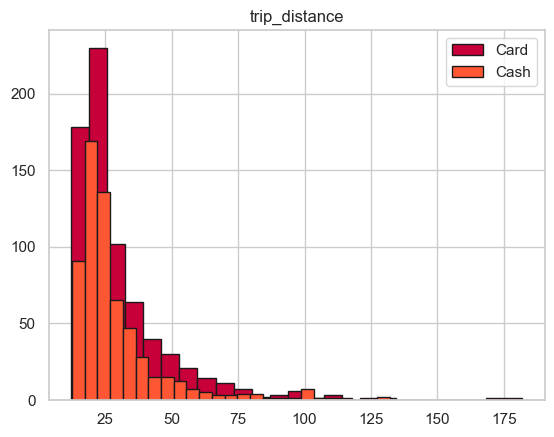

In [55]:
plt.figure()
plt.title('trip_distance')
plt.hist(df[df['payment_type']=='Card']['trip_distance'], bins = 25, label = 'Card', edgecolor = 'k', color = '#C70039')
plt.hist(df[df['payment_type']=='Cash']['trip_distance'], bins = 25, label = 'Cash', edgecolor = 'k', color = '#FF5733')
plt.legend()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue/images/trip_distance_hist.png', dpi=300, bbox_inches='tight')
plt.show()

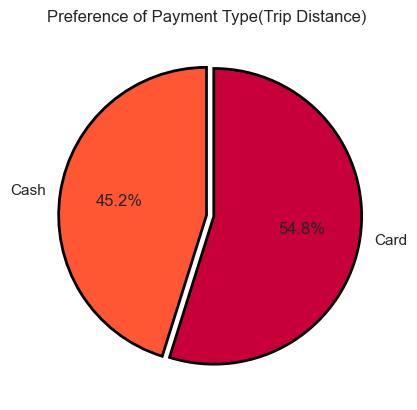

In [59]:
plt.title("Preference of Payment Type(Trip Distance)")
plt.pie([
            df[df['payment_type']=='Cash']['trip_distance'].sum(),
            df[df['payment_type']=='Card']['trip_distance'].sum()],
        labels = ['Cash', 'Card'], autopct='%1.1f%%', startangle=90, 
        colors = ['#FF5733', '#C70039'], explode = [0, 0.05],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue/images/trip_distance_pie.png', dpi=300, bbox_inches='tight')
plt.show()

# Payment Type and Duration

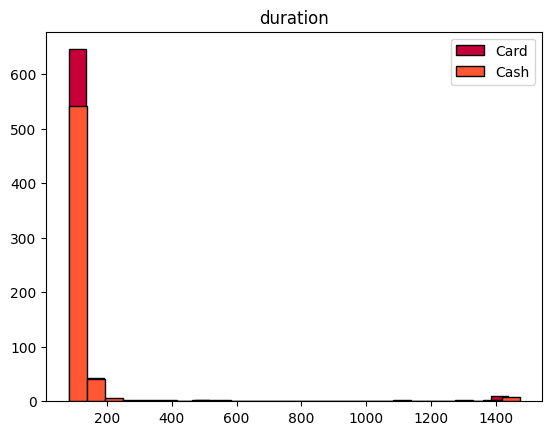

In [38]:
plt.figure()
plt.title('duration')
plt.hist(df[(df['payment_type']=='Card')]['duration'], bins = 25, label = 'Card', edgecolor = 'k', color = '#C70039')
plt.hist(df[(df['payment_type']=='Cash')]['duration'], bins = 25, label = 'Cash', edgecolor = 'k', color = '#FF5733')
plt.legend()
plt.show()

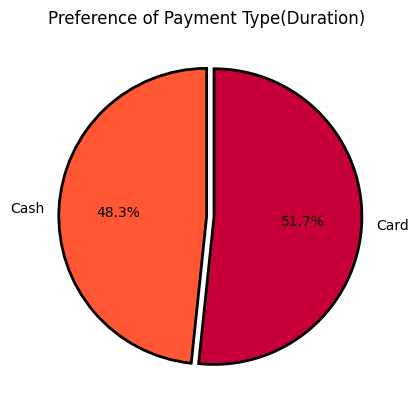

In [39]:
plt.title("Preference of Payment Type(Duration)")
plt.pie([
            df[df['payment_type']=='Cash']['duration'].sum(),
            df[df['payment_type']=='Card']['duration'].sum()],
        labels = ['Cash', 'Card'], autopct='%1.1f%%', startangle=90, 
        colors = ['#FF5733', '#C70039'], explode = [0, 0.05],
        wedgeprops = {
            'edgecolor': 'black',
            'linewidth': 2
        })
plt.show()

# A/B Testing

# TEST 1

1. Is there a statistically significant difference in average fares for those who pay through credit card vs those who pay in cash? How big is the difference with a 95% CI?

(i) In general

(ii) (a) for short trips, (b) for long trips

(iii) (a) passengers <= 4, (b) passangers > 4

(iv) 

(a) for short trips and passengers <= 4 (intracity, 4 seaters)

(b) for long trips and passengers <= 4 (intercity, 4 seaters)

(c) for short trips and passengers > 4 (intracity, large groups)

(d) for long trips and passengers > 4 (intercity, large groups)

2. Is the variance in fares for those who pay through credit card vs those who pay in cash smaller? How much? (Do credit cards target more higher ticket customers than cash?)

## SUBTEST 1

H_null: meu_credit_card_fares - meu_cash_fares = 0

H_alternate: meu_credit_fares - meu_cash_fares > 0

## SUBTEST 2

H_null: sigma_cash_fares / sigma_credit_card_fares = 1

H_alternate: sigma_cash_fares / sigma_credit_card_fares > 1

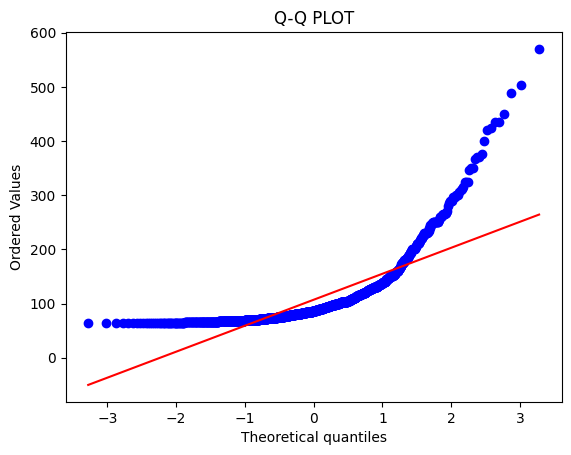

In [40]:
#checking the shape of the sample

st.probplot(df['fare_amount'], dist = 'norm', plot=plt)
plt.title("Q-Q PLOT")
plt.show()

In [41]:
# 1(i)

# Separating the groups (in general)
credit_fare = df[df['payment_type']=='Card']['fare_amount']
cash_fare = df[df['payment_type']=='Cash']['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare, cash_fare, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

# Print the results
print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

# Interpretation
if result.pvalue < alpha:
    print('Credit fare exceeds cash fare')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {1-alpha}% confidence')
else:
    print('Credit fare does not exceed cash fare')


# 2(i)

# Using Levene's test
levene_statistic, levene_p_value = st.levene(cash_fare, credit_fare)

# Print the results
print("Levene's Statistic:", levene_statistic)
print("p-value:", levene_p_value)

# Interpretation
alpha = 0.05
if levene_p_value < alpha:
    print("Reject the null hypothesis: variances are significantly different.")
else:
    print("Fail to reject the null hypothesis: variances are not significantly different.")

print("Variance of credit fares: ", np.var(credit_fare, ddof=1))
print("Variance of cash fares: ", np.var(cash_fare, ddof=1))

T statistic: 3.5079969857379236
p value: 0.0002334428394025125
Credit fare exceeds cash fare
Credit card fares exceed cash fares by at least $5.843817116865957 with 0.95% confidence
Levene's Statistic: 13.061302995762729
p-value: 0.0003126814487854241
Reject the null hypothesis: variances are significantly different.
Variance of credit fares:  4338.206421812518
Variance of cash fares:  2346.818928147498


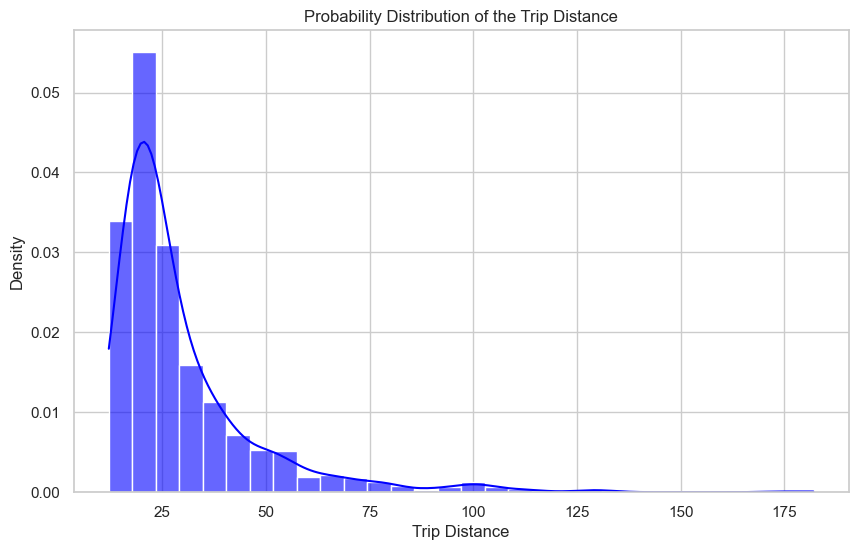

mean:  29.647737827715353


In [57]:
# Set the style of seaborn
sns.set(style='whitegrid')
# Create a figure
plt.figure(figsize=(10, 6))
# Plot the histogram
sns.histplot(df['trip_distance'], bins=30, kde=True, stat='density', color='blue', alpha=0.6)
# Add labels and title
plt.title('Probability Distribution of the Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Density')
# Show the plot
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/maximizing_revenue/images/trip_distance_kde.png', dpi=300, bbox_inches='tight')
plt.show()

print('mean: ', df['trip_distance'].mean())

In [43]:
# 1(ii)a

# Separating the groups (for short distances dist<=30)
credit_fare_short = df[(df['payment_type']=='Card') & (df['trip_distance']<=30)]['fare_amount']
cash_fare_short = df[(df['payment_type']=='Cash') & (df['trip_distance']<=30)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_short, cash_fare_short, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for short distances')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {1-alpha}% confidence for short distance(<=30)')
else:
    print('Credit fare does not exceed cash fare for short distances')

T statistic: 0.3297925110928713
p value: 0.3708161839257054
Credit fare does not exceed cash fare for short distances


In [44]:
# 1(ii)b

# Separating the groups (for long distances dist>30)
credit_fare_long = df[(df['payment_type']=='Card') & (df['trip_distance']>30)]['fare_amount']
cash_fare_long = df[(df['payment_type']=='Cash') & (df['trip_distance']>30)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_long, cash_fare_long, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for long distances')
    print(f'Credit card fares exceed cash fares by at least ${result.confidence_interval().low} with {1-alpha}% confidence for long distance(>30)')
else:
    print('Credit fare does not exceed cash fare for long distances')


T statistic: 3.0862687935286286
p value: 0.0010816450872503072
Credit fare exceeds cash fare for long distances
Credit card fares exceed cash fares by at least $10.4328434552518 with 0.95% confidence for long distance(>30)


In [45]:
# 1(iii)a

# Separating the groups (for passenger <= 4)
credit_fare_small = df[(df['payment_type']=='Card') & (df['passenger_count']<=4)]['fare_amount']
cash_fare_small = df[(df['payment_type']=='Cash') & (df['passenger_count']<=4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_small, cash_fare_small, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for 4 seaters')
    print(f'Credit card fares exceed cash fares by at least ${result.confidence_interval().low} with {(1-alpha)*100}% confidence for 4 seaters')
else:
    print('Credit fare does not exceed cash fare for 4 seaters')


T statistic: 3.5923257201313077
p value: 0.00017045421393742285
Credit fare exceeds cash fare for 4 seaters
Credit card fares exceed cash fares by at least $6.500726196694953 with 95.0% confidence for 4 seaters


In [46]:
# 1(iii)b

# Separating the groups (for passenger > 4)
credit_fare_large = df[(df['payment_type']=='Card') & (df['passenger_count']>4)]['fare_amount']
cash_fare_large = df[(df['payment_type']=='Cash') & (df['passenger_count']>4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_large, cash_fare_large, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for large groups')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {(1-alpha)*100}% confidence for large taxis')
else:
    print('Credit fare does not exceed cash fare for large groups')
    

T statistic: -0.5253315007591002
p value: 0.6996965375352782
Credit fare does not exceed cash fare for large groups


In [47]:
# 1(iv)a

# Separating the groups (for short distance and passenger <= 4)
credit_fare_short_small = df[(df['payment_type']=='Card') & (df['trip_distance']<=30) & (df['passenger_count']<=4)]['fare_amount']
cash_fare_short_small = df[(df['payment_type']=='Cash') & (df['trip_distance']<=30) & (df['passenger_count']<=4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_short_small, cash_fare_short_small, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for short distance travel in 4 seaters')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {(1-alpha)*100}% confidence for short distance travel in 4 seaters')
else:
    print('Credit fare does not exceed cash fare for short distance travel in 4 seaters')
    

T statistic: 0.38451049658216135
p value: 0.3503488544731475
Credit fare does not exceed cash fare for short distance travel in 4 seaters


In [48]:
# 1(iv)b

# Separating the groups (for long distance and passenger <= 4)
credit_fare_long_small = df[(df['payment_type']=='Card') & (df['trip_distance']>30) & (df['passenger_count']<=4)]['fare_amount']
cash_fare_long_small = df[(df['payment_type']=='Cash') & (df['trip_distance']>30) & (df['passenger_count']<=4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_long_small, cash_fare_long_small, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for long distance travel in 4 seaters')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {(1-alpha)*100}% confidence for long distance travel in 4 seaters')
else:
    print('Credit fare does not exceed cash fare for long distance travel in 4 seaters')
    

T statistic: 2.930672284673706
p value: 0.0017906114335226146
Credit fare exceeds cash fare for long distance travel in 4 seaters
Credit card fares exceed cash fares by at least $9.693447477861222 with 95.0% confidence for long distance travel in 4 seaters


In [49]:
# 1(iv)c

# Separating the groups (for short distance and passenger > 4)
credit_fare_short_large = df[(df['payment_type']=='Card') & (df['trip_distance']<=30) & (df['passenger_count']>4)]['fare_amount']
cash_fare_short_large = df[(df['payment_type']=='Cash') & (df['trip_distance']<=30) & (df['passenger_count']>4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_short_large, cash_fare_short_large, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for short distance travel in large groups')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {(1-alpha)*100}% confidence for short distance travel in large groups')
else:
    print('Credit fare does not exceed cash fare for short distance travel in large groups')
    

T statistic: -0.0893844827944221
p value: 0.535485405929322
Credit fare does not exceed cash fare for short distance travel in large groups


In [50]:
# 1(iv)d

# Separating the groups (for long distance and passenger > 4)
credit_fare_short_small = df[(df['payment_type']=='Card') & (df['trip_distance']>30) & (df['passenger_count']>4)]['fare_amount']
cash_fare_short_small = df[(df['payment_type']=='Cash') & (df['trip_distance']>30) & (df['passenger_count']>4)]['fare_amount']

# Performing Welch's T Test 2 way, greater
result = st.ttest_ind(credit_fare_short_small, cash_fare_short_small, 
                      equal_var=False, alternative='greater')

alpha = 0.05
ci = result.confidence_interval(confidence_level=(1-alpha))

print(f'T statistic: {result.statistic}')
print(f'p value: {result.pvalue}')

if result.pvalue < alpha:
    print('Credit fare exceeds cash fare for long distance travel in large groups')
    print(f'Credit card fares exceed cash fares by at least ${ci.low} with {(1-alpha)*100}% confidence for short distance travel in large groups')
else:
    print('Credit fare does not exceed cash fare for long distance travel in large groups')
    

T statistic: 0.32593684599577544
p value: 0.374072111633944
Credit fare does not exceed cash fare for long distance travel in large groups


In [52]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
1365,1,21.40,Card,92.8,120.916667
4879,1,25.42,Card,115.5,137.633333
15716,1,12.40,Card,67.0,95.983333
24505,1,34.20,Cash,139.5,179.466667
26670,1,15.44,Cash,76.0,1030.800000
...,...,...,...,...,...
12588809,3,17.60,Cash,67.5,114.833333
12589240,1,21.06,Cash,80.0,135.216667
12606409,2,39.38,Cash,159.5,81.466667
12656947,1,13.40,Card,89.5,109.150000


# Conclusion

## Credit paying customers pays higher fares than cash paying customers in general. 

## The average of credit paying customer is a single customer and travel long distances.